# Conway's Game of Life: Cellular Automaton Simulator

Conway's Game of Life is a tiny world where simple rules create surprisingly complex patterns.

John Conway introduced Life in 1970, and it became a landmark example of emergence: gliders, oscillators, and self-organizing structures appear without any central controller. It connects recreational math to physics, biology, complexity science, and the idea that local rules can create global behavior.

In this notebook, you will build it with small objects: cells, a grid, generations, and a runner that evolves the world step by step.

<details>
<summary>Big idea</summary>

Each cell looks at its eight neighbors. A live cell may survive or die. A dead cell may become alive. Everyone updates at the same time.

</details>

## 1. The Mental Model

Game of Life is a cellular automaton:

- **Cell**: one square on the grid
- **Alive**: marked with `O`
- **Dead**: marked with `.`
- **Neighbor**: one of the eight surrounding cells
- **Generation**: one full update of the whole grid
- **Rule**: a local decision based on live-neighbor count

The magic is that every cell follows the same small rule at the same time.

<details>
<summary>The four rules</summary>

1. A live cell with fewer than `2` live neighbors dies.
2. A live cell with `2` or `3` live neighbors survives.
3. A live cell with more than `3` live neighbors dies.
4. A dead cell with exactly `3` live neighbors becomes alive.

</details>

## 2. Build the Objects

Implementation plan:

1. `Cell` stores a row and column.
2. `LifeGrid` stores the board size and live cells.
3. `GenerationStep` records snapshots for replay.
4. `GameOfLifeRunner` evolves the grid.
5. `LifeReplay` prints generations cleanly.

<details>
<summary>Implementation hint</summary>

Store only live cells in a `set`. Dead cells do not need to be stored because every cell not in the set is dead.

</details>

**Object model.** Define `Cell`, the named objects used by the next examples.


In [ ]:
from dataclasses import dataclass

@dataclass(frozen=True, order=True)
class Cell:
    row: int
    col: int

    def neighbors(self) -> list["Cell"]:
        nearby = []
        for row_step in [-1, 0, 1]:
            for col_step in [-1, 0, 1]:
                if row_step == 0 and col_step == 0:
                    continue
                nearby.append(Cell(self.row + row_step, self.col + col_step))
        return nearby

    def __str__(self) -> str:
        return f"({self.row}, {self.col})"


**State model.** Define `LifeGrid`, the data structure the lesson will operate on.


In [ ]:
@dataclass
class LifeGrid:
    height: int
    width: int
    alive: set[Cell]

    @classmethod
    def from_lines(cls, lines: list[str]) -> "LifeGrid":
        height = len(lines)
        width = len(lines[0]) if lines else 0
        alive = set()

        for row, line in enumerate(lines):
            if len(line) != width:
                raise ValueError("Every grid row must have the same width.")
            for col, marker in enumerate(line):
                if marker == "O":
                    alive.add(Cell(row, col))

        return cls(height=height, width=width, alive=alive)

    def is_inside(self, cell: Cell) -> bool:
        return 0 <= cell.row < self.height and 0 <= cell.col < self.width

    def live_neighbor_count(self, cell: Cell) -> int:
        return sum(neighbor in self.alive for neighbor in cell.neighbors() if self.is_inside(neighbor))

    def next_generation(self) -> "LifeGrid":
        candidates = set(self.alive)
        for cell in self.alive:
            candidates.update(neighbor for neighbor in cell.neighbors() if self.is_inside(neighbor))

        next_alive = set()
        for cell in candidates:
            count = self.live_neighbor_count(cell)
            if cell in self.alive and count in [2, 3]:
                next_alive.add(cell)
            elif cell not in self.alive and count == 3:
                next_alive.add(cell)

        return LifeGrid(self.height, self.width, next_alive)

    def draw(self) -> str:
        rows = []
        for row in range(self.height):
            markers = []
            for col in range(self.width):
                markers.append("O" if Cell(row, col) in self.alive else ".")
            rows.append("".join(markers))
        return "\n".join(rows)


**Trace model.** Define `GenerationStep`, the structure used to capture replayable algorithm state.


In [ ]:
@dataclass
class GenerationStep:
    generation: int
    grid: LifeGrid
    births: set[Cell]
    deaths: set[Cell]
    survivors: set[Cell]
    note: str


**Algorithm engine.** Define `GameOfLifeRunner`, the class that runs the main simulation or algorithm.


In [ ]:
class GameOfLifeRunner:
    def __init__(self, starting_grid: LifeGrid):
        self.starting_grid = starting_grid

    def run(self, generations: int) -> list[GenerationStep]:
        steps = [
            GenerationStep(
                generation=0,
                grid=self.starting_grid,
                births=set(),
                deaths=set(),
                survivors=self.starting_grid.alive.copy(),
                note="Starting pattern.",
            )
        ]
        current = self.starting_grid

        for generation in range(1, generations + 1):
            next_grid = current.next_generation()
            births = next_grid.alive - current.alive
            deaths = current.alive - next_grid.alive
            survivors = current.alive & next_grid.alive
            steps.append(
                GenerationStep(
                    generation=generation,
                    grid=next_grid,
                    births=births,
                    deaths=deaths,
                    survivors=survivors,
                    note="Apply all cell rules at once.",
                )
            )
            current = next_grid

        return steps


## 3. Create a Starting Pattern

Now create a small pattern called a glider. It moves diagonally over time, even though each cell only follows local rules.

<details>
<summary>Hint: why gliders are fun</summary>

A glider is not one object moving. It is a pattern repeatedly dying and being reborn in nearby cells.

</details>

In [15]:
glider_lines = [
    "........",
    "..O.....",
    "...O....",
    ".OOO....",
    "........",
    "........",
    "........",
    "........",
]

glider = LifeGrid.from_lines(glider_lines)

print("Generation 0:")
print(glider.draw())

Generation 0:
........
..O.....
...O....
.OOO....
........
........
........
........


## 4. Run the Simulation

The runner returns a list of `GenerationStep` objects. Each step stores:

- the generation number
- the grid snapshot
- cells that were born
- cells that died
- cells that survived

<details>
<summary>Quick check</summary>

A glider should keep five live cells while its shape shifts across the board.

</details>

In [16]:
runner = GameOfLifeRunner(glider)
steps = runner.run(generations=4)

for step in steps:
    print(f"Generation {step.generation} | alive cells: {len(step.grid.alive)}")
    print(step.grid.draw())
    print()

Generation 0 | alive cells: 5
........
..O.....
...O....
.OOO....
........
........
........
........

Generation 1 | alive cells: 5
........
........
.O.O....
..OO....
..O.....
........
........
........

Generation 2 | alive cells: 5
........
........
...O....
.O.O....
..OO....
........
........
........

Generation 3 | alive cells: 5
........
........
..O.....
...OO...
..OO....
........
........
........

Generation 4 | alive cells: 5
........
........
...O....
....O...
..OOO...
........
........
........



## 5. Replay Births and Deaths

The replay shows the pattern plus the bookkeeping behind it: which cells were born, which died, and which survived.

<details>
<summary>Hint: why update all at once?</summary>

Every cell must read the old generation, then all changes apply together. Updating cells one by one would create a different game.

</details>

In [9]:
class LifeReplay:
    def __init__(self, steps: list[GenerationStep]):
        self.steps = steps

    def show(self, limit: int | None = None) -> None:
        selected_steps = self.steps if limit is None else self.steps[:limit]

        for step in selected_steps:
            print(f"Generation {step.generation}: {step.note}")
            print("  born    :", self._format_cells(step.births))
            print("  died    :", self._format_cells(step.deaths))
            print("  survived:", self._format_cells(step.survivors))
            print(step.grid.draw())
            print()

    def _format_cells(self, cells: set[Cell]) -> str:
        return ", ".join(str(cell) for cell in sorted(cells)) or "none"


replay = LifeReplay(steps)
replay.show(limit=3)

Generation 0: Starting pattern.
  born    : none
  died    : none
  survived: (1, 2), (2, 3), (3, 1), (3, 2), (3, 3)
........
..O.....
...O....
.OOO....
........
........
........
........

Generation 1: Apply all cell rules at once.
  born    : (2, 1), (4, 2)
  died    : (1, 2), (3, 1)
  survived: (2, 3), (3, 2), (3, 3)
........
........
.O.O....
..OO....
..O.....
........
........
........

Generation 2: Apply all cell rules at once.
  born    : (3, 1), (4, 3)
  died    : (2, 1), (3, 2)
  survived: (2, 3), (3, 3), (4, 2)
........
........
...O....
.O.O....
..OO....
........
........
........



## 6. Your Experiments

Try changing one thing at a time:

- Move one live cell in the glider
- Add a second glider
- Try a three-cell line called a blinker
- Make the board larger

<details>
<summary>Challenge</summary>

Predict whether a pattern will vanish, freeze, repeat, or travel. Then run the simulation and compare.

</details>

In [12]:
blinker_lines = [
    ".......",
    ".......",
    "..OOO..",
    ".......",
    ".......",
]

blinker = LifeGrid.from_lines(blinker_lines)
blinker_steps = GameOfLifeRunner(blinker).run(generations=4)

for step in blinker_steps:
    print(f"Generation {step.generation}")
    print(step.grid.draw())
    print()

Generation 0
.......
.......
..OOO..
.......
.......

Generation 1
.......
...O...
...O...
...O...
.......

Generation 2
.......
.......
..OOO..
.......
.......

Generation 3
.......
...O...
...O...
...O...
.......

Generation 4
.......
.......
..OOO..
.......
.......



## 7. Visual Replay Upgrade

The printed boards are useful for debugging, but the Game of Life is much easier to understand visually.

This section adds richer plots and animations:

- live cells glow against a dark board,
- gliders move across a larger grid,
- births, deaths, and survivors get separate colors,
- pattern families can be compared side by side.

**Helper functions.** Define `grid_to_array`, `transition_to_array` so the later cells stay focused on behavior.


In [ ]:
import numpy as np

import matplotlib.pyplot as plt

from matplotlib import animation

from matplotlib.colors import ListedColormap, BoundaryNorm

from IPython.display import HTML

life_cmap = ListedColormap(["#101820", "#F2AA4C"])

transition_cmap = ListedColormap(["#101820", "#D95D39", "#2A9D8F", "#F4D35E"])

transition_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], transition_cmap.N)

def grid_to_array(grid: LifeGrid) -> np.ndarray:
    array = np.zeros((grid.height, grid.width), dtype=int)
    for cell in grid.alive:
        array[cell.row, cell.col] = 1
    return array

def transition_to_array(step: GenerationStep) -> np.ndarray:
    array = np.zeros((step.grid.height, step.grid.width), dtype=int)
    for cell in step.deaths:
        array[cell.row, cell.col] = 1
    for cell in step.survivors:
        array[cell.row, cell.col] = 2
    for cell in step.births:
        array[cell.row, cell.col] = 3
    return array


**Visual helper.** Define `style_life_axis`, `plot_life_grid`, `plot_transition`, which turns state into something students can inspect.


In [ ]:
def style_life_axis(ax, title: str) -> None:
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    for spine in ax.spines.values():
        spine.set_visible(False)

def plot_life_grid(grid: LifeGrid, title: str, ax=None) -> None:
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(grid_to_array(grid), cmap=life_cmap, interpolation="nearest")
    style_life_axis(ax, title)

def plot_transition(step: GenerationStep, title: str, ax=None) -> None:
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(transition_to_array(step), cmap=transition_cmap, norm=transition_norm, interpolation="nearest")
    style_life_axis(ax, title)


**Helper functions.** Define `animate_life` so the later cells stay focused on behavior.


In [ ]:
def animate_life(steps: list[GenerationStep], title: str, interval: int = 450) -> HTML:
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    image = ax.imshow(grid_to_array(steps[0].grid), cmap=life_cmap, interpolation="nearest", animated=True)
    style_life_axis(ax, f"{title} | generation 0")

    def update(frame_index: int):
        step = steps[frame_index]
        image.set_array(grid_to_array(step.grid))
        ax.set_title(f"{title} | generation {step.generation} | alive {len(step.grid.alive)}")
        return (image,)

    life_animation = animation.FuncAnimation(
        fig,
        update,
        frames=len(steps),
        interval=interval,
        blit=True,
    )
    plt.close(fig)
    return HTML(life_animation.to_jshtml())


## 8. Animate a Glider

A glider is the perfect visual example because it appears to travel, even though the rules only update local cells.

In [18]:
large_glider = LifeGrid(
    height=28,
    width=28,
    alive={
        Cell(2, 3),
        Cell(3, 4),
        Cell(4, 2),
        Cell(4, 3),
        Cell(4, 4),
    },
)

large_glider_steps = GameOfLifeRunner(large_glider).run(generations=36)
animate_life(large_glider_steps, "Glider")

## 9. Snapshot Panels

A panel view makes the movement easier to scan: each frame is one generation, and the route of the glider becomes visible across the grid.

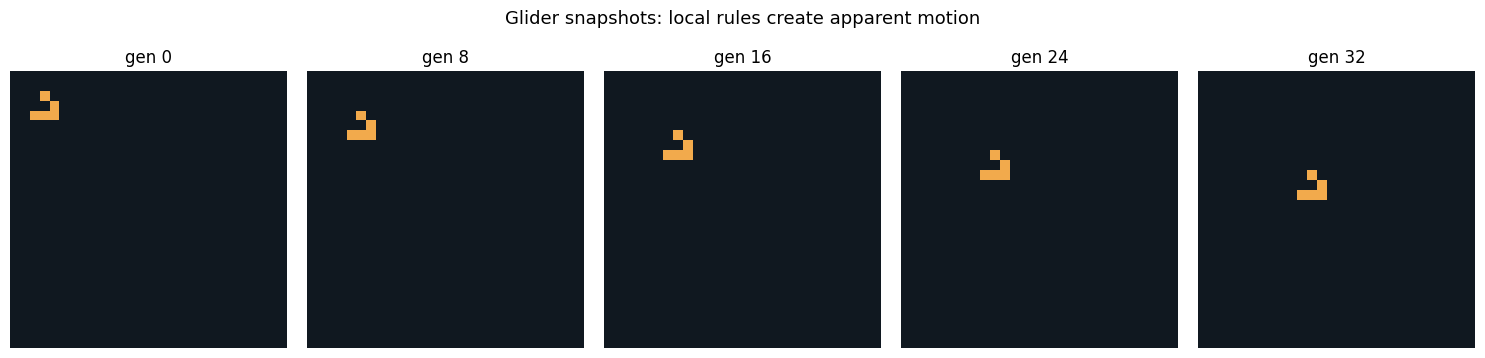

In [19]:
selected_generations = [0, 8, 16, 24, 32]
fig, axes = plt.subplots(1, len(selected_generations), figsize=(15, 3.4))

for ax, generation in zip(axes, selected_generations):
    step = large_glider_steps[generation]
    plot_life_grid(step.grid, title=f"gen {generation}", ax=ax)

fig.suptitle("Glider snapshots: local rules create apparent motion", fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

## 10. Birth, Survival, and Death Colors

The old text replay lists born and dead cells. This version shows the same rule bookkeeping visually:

- red: died this generation,
- green: survived,
- gold: born.

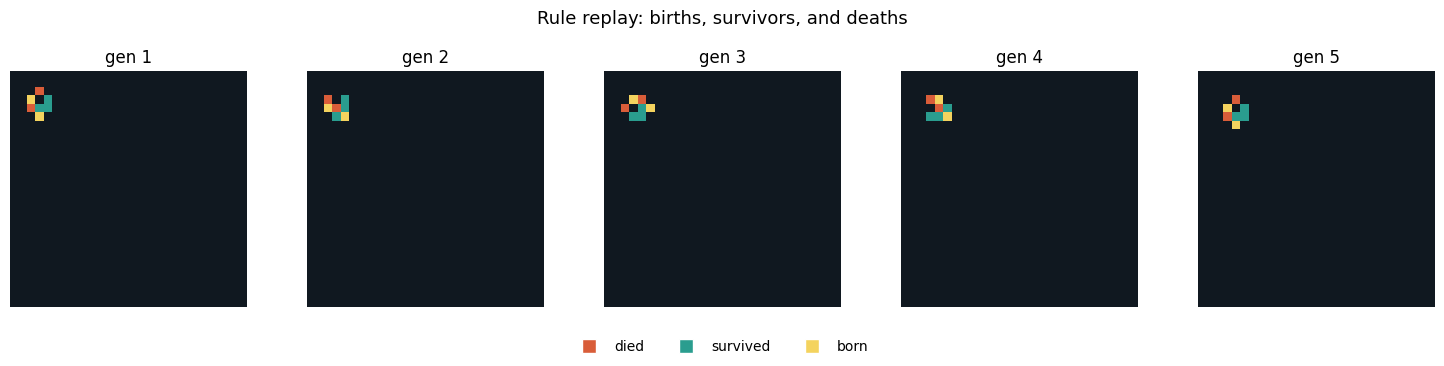

In [20]:
transition_generations = [1, 2, 3, 4, 5]
fig, axes = plt.subplots(1, len(transition_generations), figsize=(15, 3.4))

for ax, generation in zip(axes, transition_generations):
    step = large_glider_steps[generation]
    plot_transition(step, title=f"gen {generation}", ax=ax)

legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#D95D39", markersize=10, label="died"),
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#2A9D8F", markersize=10, label="survived"),
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor="#F4D35E", markersize=10, label="born"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Rule replay: births, survivors, and deaths", fontsize=13, y=1.04)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

## 11. Pattern Gallery

Different starting shapes produce different behavior. This gallery compares common families:

- a still life freezes,
- oscillators repeat,
- a glider travels.

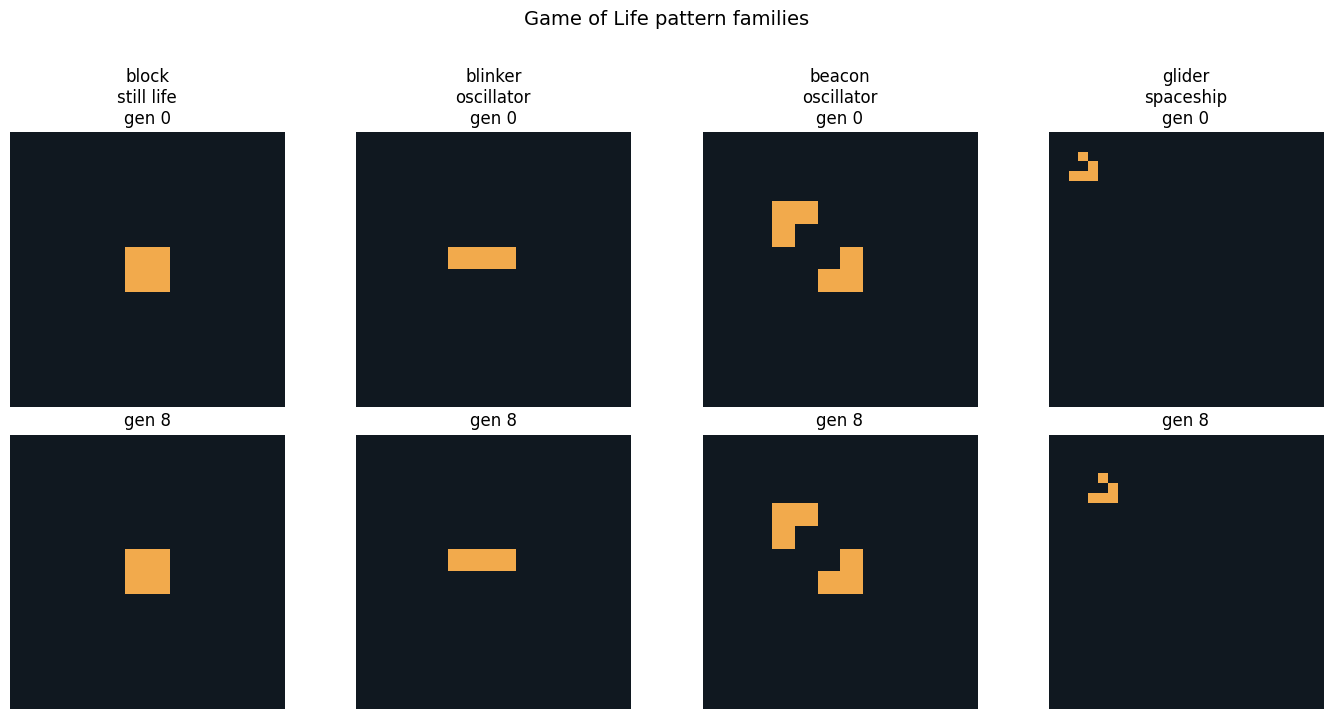

In [21]:
def grid_from_coordinates(height: int, width: int, coordinates: set[tuple[int, int]]) -> LifeGrid:
    return LifeGrid(height=height, width=width, alive={Cell(row, col) for row, col in coordinates})


pattern_gallery = {
    "block\nstill life": grid_from_coordinates(12, 12, {(5, 5), (5, 6), (6, 5), (6, 6)}),
    "blinker\noscillator": grid_from_coordinates(12, 12, {(5, 4), (5, 5), (5, 6)}),
    "beacon\noscillator": grid_from_coordinates(12, 12, {(3, 3), (3, 4), (4, 3), (5, 6), (6, 5), (6, 6)}),
    "glider\nspaceship": large_glider,
}

fig, axes = plt.subplots(2, len(pattern_gallery), figsize=(14, 7))
for col, (name, starting_grid) in enumerate(pattern_gallery.items()):
    gallery_steps = GameOfLifeRunner(starting_grid).run(generations=8)
    plot_life_grid(gallery_steps[0].grid, title=f"{name}\ngen 0", ax=axes[0, col])
    plot_life_grid(gallery_steps[-1].grid, title="gen 8", ax=axes[1, col])

fig.suptitle("Game of Life pattern families", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 12. Visual Takeaway

The printed boards are still useful for learning the data structure, but the animations and color panels make the behavior easier to see:

- live cells show the pattern itself,
- color transitions reveal the rule mechanics,
- snapshot panels show motion over time,
- the gallery compares different pattern families.

<details>
<summary>Course connection</summary>

This is the same simulation as before. The upgrade is the view layer: the model stays object-oriented, and the visualizations make each generation feel alive.

</details>

## Visual Trace + Rigor Studio

**Problem frame.** Watch global behavior emerge from local neighbor rules.

**Interactive animation target.** Animate generations on a grid with live-cell count and pattern classification.

**Correctness handle.** The next board is computed synchronously from the current board, not updated in place.

**Complexity handle.** O(generations * rows * columns).

**Failure mode to test.** In-place updates accidentally let future cells influence the same generation.

**Studio task.** Trace a glider and one random seed; classify death, stability, oscillator, or movement.


In [ ]:
from pathlib import Path
import sys
from IPython.display import display

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "courseware").exists():
        sys.path.insert(0, str(candidate))
        break

from courseware import AlgorithmPlayer, game_of_life_trace, render_grid, render_trace_table

glider = [
    [0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
]
trace = game_of_life_trace(glider, steps=12)
display(render_trace_table(trace))
AlgorithmPlayer(trace, render_grid).display()
